In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Collect metrics for plotting
metrics_dict = {}

# Load saved predictions 
models = ["132kb_mouse", "132kb_human", "132kb_human_mouse", "524kb_human_mouse"]
for model in models:
    for pred_sps in ["rat", "mouse", "human"]:
        # Construct prediction directory path
        pred_dir = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/{model}/preds_{pred_sps}"
        # Infer trained species from model name
        model_sps = model.split("_")[1:]
        for sps in model_sps:
            print(f"Model: {model}, Prediction Species: {pred_sps}, Model Species: {sps}")
            # Load predictions
            metrics_fn = f"{pred_dir}/metrics.json"
            if os.path.exists(metrics_fn):
                print(f"  Loading metrics from {metrics_fn}")
                with open(metrics_fn, "r") as f:
                    metrics = json.load(f)
            # Collect metrics for plotting
            metrics_dict[(model, pred_sps, sps)] = metrics

Model: 132kb_mouse, Prediction Species: rat, Model Species: mouse
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse/preds_rat/metrics.json
Model: 132kb_mouse, Prediction Species: mouse, Model Species: mouse
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse/preds_mouse/metrics.json
Model: 132kb_mouse, Prediction Species: human, Model Species: mouse
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse/preds_human/metrics.json
Model: 132kb_human, Prediction Species: rat, Model Species: human
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human/preds_rat/metrics.json
Model: 132kb_human, Prediction Species: mouse, Model Species: human
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human/preds_mouse/metrics.json
Model: 132kb_human, Prediction Species: human, Model Species: human
  Loading metri

In [4]:
# Colors for plotting
CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}
TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Midbrain': '#34b3e6',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

## Splice site classification (AUPRC per class)

In [5]:
# Extract classification metrics (AUPRC per class)
classification_data = []

# Mapping from class names to indices
class_name_to_idx = {
    'Donor+': 0,
    'Acceptor+': 1,
    'Donor-': 2,
    'Acceptor-': 3
}

for (model, pred_sps, model_sps), metrics in metrics_dict.items():
    if pred_sps in metrics:
        species_metrics = metrics[pred_sps]
        
        # Per-class AUPRC (stored in "per_class_auprc" dict)
        if 'per_class_auprc' in species_metrics:
            for class_name, auprc_value in species_metrics['per_class_auprc'].items():
                class_idx = class_name_to_idx.get(class_name)
                if class_idx is not None:
                    classification_data.append({
                        'model': model,
                        'pred_species': pred_sps,
                        'model_species': model_sps,
                        'class_idx': class_idx,
                        'class_label': CLASS_LABELS[class_idx],
                        'auprc': auprc_value
                    })
        
        # Binary AUPRC (any splice site vs background)
        if 'binary_auprc' in species_metrics:
            classification_data.append({
                'model': model,
                'pred_species': pred_sps,
                'model_species': model_sps,
                'class_idx': 4,
                'class_label': 'binary (any)',
                'auprc': species_metrics['binary_auprc']
            })

df_classification = pd.DataFrame(classification_data)
print(f"Extracted {len(df_classification)} classification metrics")
df_classification.head(10)

Extracted 80 classification metrics


,model,pred_species,model_species,class_idx,class_label,auprc
0,132kb_mouse,rat,mouse,0,donor +,0.843731
1,132kb_mouse,rat,mouse,1,acceptor +,0.808584
2,132kb_mouse,rat,mouse,2,donor -,0.834637
3,132kb_mouse,rat,mouse,3,acceptor -,0.827076
4,132kb_mouse,rat,mouse,4,binary (any),0.870654
5,132kb_mouse,mouse,mouse,0,donor +,0.775506
6,132kb_mouse,mouse,mouse,1,acceptor +,0.773717
7,132kb_mouse,mouse,mouse,2,donor -,0.762161
8,132kb_mouse,mouse,mouse,3,acceptor -,0.761246
9,132kb_mouse,mouse,mouse,4,binary (any),0.879598


Plot grouped barplot of classification AUPRC

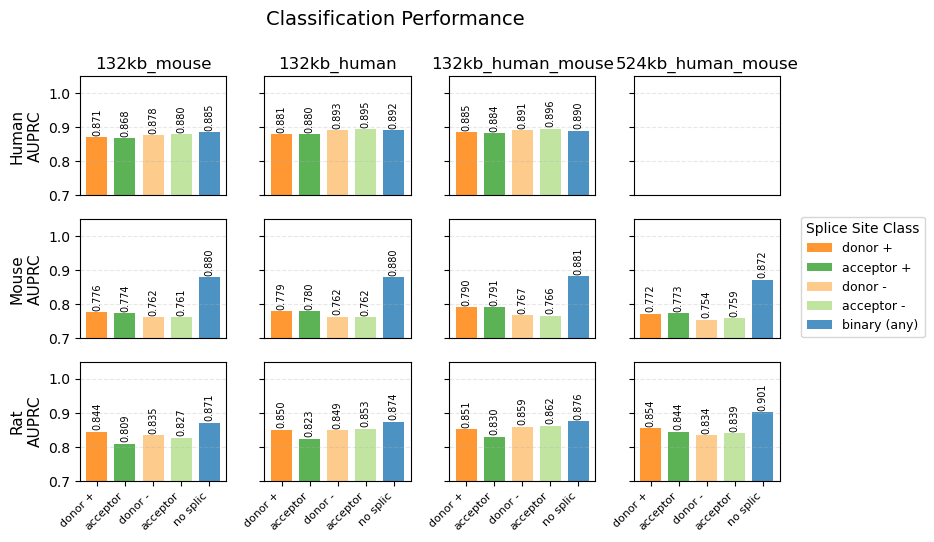

In [6]:
# Grouped barplot: Classification AUPRC by class, organized in grid
# Rows = evaluation species, Columns = models
import matplotlib.pyplot as plt
import numpy as np

# Get unique models and prediction species
models = models #sorted(df_classification['model'].unique())
pred_species_list = sorted(df_classification['pred_species'].unique())
classes = sorted(df_classification['class_idx'].unique())

n_models = len(models)
n_species = len(pred_species_list)
n_classes = len(classes)

# Create subplot grid: rows = species, cols = models
fig, axes = plt.subplots(n_species, n_models, figsize=(n_models * 2, n_species * 1.8), 
                         squeeze=False, sharex=False, sharey=True)

bar_width = 0.25
x = np.arange(n_classes)

# Plot each species × model combination
for species_idx, pred_sps in enumerate(pred_species_list):
    for model_idx, model in enumerate(models):
        ax = axes[species_idx, model_idx]
        
        # Filter data for this species and model
        subset = df_classification[
            (df_classification['pred_species'] == pred_sps) & 
            (df_classification['model'] == model)
        ]
        
        if len(subset) > 0:
            # Plot bars for each class
            for i, class_idx in enumerate(classes):
                class_data = subset[subset['class_idx'] == class_idx]
                
                if len(class_data) > 0:
                    auprc_value = class_data['auprc'].values[0]
                    
                    # Use class colors
                    color = CLASS_COLORS.get(class_idx, '#888888')
                    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
                    if class_idx == 4:  # Binary
                        label = 'binary'
                        color = '#1f78b4'
                    
                    bar = ax.bar(i, auprc_value, bar_width * 3, color=color, alpha=0.8,
                          label=label if model_idx == 0 and species_idx == 0 else "")
                    
                    # Add value on top of bar
                    ax.text(i, auprc_value + 0.005, f'{auprc_value:.3f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)
        
        # Customize subplot
        ax.set_ylim(0.7, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Set title for top row (model names)
        if species_idx == 0:
            ax.set_title(model)
        
        # Set ylabel for leftmost column (species names)
        if model_idx == 0:
            ax.set_ylabel(f'{pred_sps.capitalize()}\nAUPRC', 
                         fontsize=11)
        
        # Only show x-ticks on bottom row
        if species_idx == n_species - 1:
            ax.set_xticks(range(n_classes))
            ax.set_xticklabels([CLASS_LABELS.get(c, 'binary')[:8] for c in classes], 
                              rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticks([])

# Add overall title
fig.suptitle('Classification Performance', 
             fontsize=14, y=0.995)

# Create legend (only once, outside subplots)
handles = []
labels = []
for class_idx in classes:
    color = CLASS_COLORS.get(class_idx, '#888888')
    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
    if class_idx == 4:
        label = 'binary (any)'
        color = '#1f78b4'
    handles.append(plt.Rectangle((0,0),1,1, fc=color, alpha=0.8))
    labels.append(label)

fig.legend(handles, labels, title='Splice Site Class', 
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


## Splice usage metrics (per-condition correlations)

In [7]:
# Extract per-condition usage correlations from saved predictions
# We'll compute correlations from the usage .npz files and map to tissues via metadata

from scipy.stats import pearsonr
from pathlib import Path

# Fixed ordering for models and heads
MODEL_ORDER = ["132kb_human", "132kb_mouse", "132kb_human_mouse", "524kb_human_mouse"]
HEAD_ORDER = ["human", "mouse"]

# Colors for model/head combos
models_color = {
    "132kb_human (head: human)": "#1f77b4",
    "132kb_mouse (head: mouse)": "#de6d0a",
    "132kb_human_mouse (head: human)": "#6baed6",
    "132kb_human_mouse (head: mouse)": "#fd8d3c",
    "524kb_human_mouse (head: human)": "#9ecae1",
    "524kb_human_mouse (head: mouse)": "#fdd0a2"
}
    

def get_pooled_r(metrics_entry, pred_sps, usage_head_species):
    """Look up the pooled Pearson r for a given species/head from metrics dict entry.
    
    usage_by_head keys may be either the bare species name ("human") or
    prefixed with "from_" ("from_human"), so we try both.
    """
    species_m = metrics_entry.get(pred_sps, {})
    by_head = species_m.get('usage_by_head', {})
    if by_head:
        # Try bare name first, then "from_<name>"
        for key in (usage_head_species, f"from_{usage_head_species}"):
            val = by_head.get(key, {}).get('usage_pearson_r')
            if val is not None:
                return val
        return None
    return species_m.get('usage_pearson_r', None)

usage_data_list = []

for (model, pred_sps, model_sps), metrics in metrics_dict.items():
    pred_dir = Path(f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/{model}/preds_{pred_sps}")
    
    # Load usage metadata to map conditions to tissues
    species_map = {'human': 'Homo_sapiens', 'mouse': 'Mus_musculus', 'rat': 'Rattus_norvegicus'}
    metadata_path = Path(f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/{species_map[pred_sps]}/usage.json")
    
    if not metadata_path.exists():
        print(f"Metadata not found: {metadata_path}")
        continue
    
    with open(metadata_path) as f:
        usage_metadata = json.load(f)
    condition_labels = usage_metadata.get("condition_labels", {})
    idx_to_name = {int(v): k for k, v in condition_labels.items()}
    
    # Determine which usage files to load
    usage_files = []
    
    # Check for cross-species predictions (new format)
    if model_sps != pred_sps:
        # Cross-species evaluation with multiple heads
        if (pred_dir / f"usage_{pred_sps}_from_{model_sps}.npz").exists():
            usage_files.append((f"usage_{pred_sps}_from_{model_sps}.npz", model_sps))
    elif model_sps == pred_sps:
        # Same-species or old format
        usage_files.append((f"usage_{pred_sps}.npz", model_sps))
    
    for usage_file, usage_head_species in usage_files:
        usage_path = pred_dir / usage_file
        
        if not usage_path.exists():
            print(f"Usage file not found: {usage_path}")
            continue
        
        # Pooled Pearson r from metrics.json
        pooled_r = get_pooled_r(metrics, pred_sps, usage_head_species)
        
        # Load usage predictions
        usage_data = np.load(usage_path)
        
        # Compute per-condition correlations using summary statistics
        stats_cond_ids = usage_data['stats_cond_ids']
        stats_n = usage_data['stats_n']
        stats_sum_pred = usage_data['stats_sum_pred']
        stats_sum_true = usage_data['stats_sum_true']
        stats_sum_pred2 = usage_data['stats_sum_pred2']
        stats_sum_true2 = usage_data['stats_sum_true2']
        stats_sum_prod = usage_data['stats_sum_prod']
        
        for i, cond_idx in enumerate(stats_cond_ids):
            n = stats_n[i]
            if n <= 1:
                continue
            
            # Pearson r from summary statistics
            numerator = n * stats_sum_prod[i] - stats_sum_pred[i] * stats_sum_true[i]
            denom_pred = n * stats_sum_pred2[i] - stats_sum_pred[i] ** 2
            denom_true = n * stats_sum_true2[i] - stats_sum_true[i] ** 2
            
            if denom_pred > 0 and denom_true > 0:
                r = numerator / np.sqrt(denom_pred * denom_true)
            else:
                continue
            
            # Get condition name and extract tissue
            cond_name = idx_to_name.get(int(cond_idx), f"unknown_{cond_idx}")
            tissue = cond_name.rsplit('_', 1)[0] if '_' in cond_name else cond_name
            
            try:
                timepoint = int(cond_name.rsplit('_', 1)[1]) if '_' in cond_name else None
            except:
                timepoint = None
            
            usage_data_list.append({
                'model': model,
                'pred_species': pred_sps,
                'model_species': model_sps,
                'usage_head_species': usage_head_species,
                'tissue': tissue,
                'condition_idx': int(cond_idx),
                'condition_name': cond_name,
                'timepoint': timepoint,
                'correlation': float(r),
                'pooled_r': float(pooled_r) if pooled_r is not None else float('nan'),
                'n_sites': int(n)
            })

df_usage = pd.DataFrame(usage_data_list)
print(f"Extracted {len(df_usage)} per-condition usage correlations")
print(f"Tissues: {sorted(df_usage['tissue'].unique())}")
df_usage.head(10)


Extracted 1102 per-condition usage correlations
Tissues: ['Brain', 'Cerebellum', 'Heart', 'Kidney', 'Liver', 'Midbrain', 'Ovary', 'Testis']


,model,pred_species,model_species,usage_head_species,tissue,condition_idx,condition_name,timepoint,correlation,pooled_r,n_sites
0,132kb_mouse,rat,mouse,mouse,Brain,0,Brain_1,1,0.764884,0.658033,132082
1,132kb_mouse,rat,mouse,mouse,Brain,1,Brain_10,10,0.777980,0.658033,132082
2,132kb_mouse,rat,mouse,mouse,Brain,2,Brain_11,11,0.768664,0.658033,132082
3,132kb_mouse,rat,mouse,mouse,Brain,4,Brain_13,13,0.749947,0.658033,132082
4,132kb_mouse,rat,mouse,mouse,Brain,5,Brain_14,14,0.747079,0.658033,132082
5,132kb_mouse,rat,mouse,mouse,Brain,6,Brain_2,2,0.785779,0.658033,132082
6,132kb_mouse,rat,mouse,mouse,Brain,8,Brain_4,4,0.797694,0.658033,132082
7,132kb_mouse,rat,mouse,mouse,Brain,9,Brain_5,5,0.774361,0.658033,132082
8,132kb_mouse,rat,mouse,mouse,Brain,11,Brain_7,7,0.778565,0.658033,132082
9,132kb_mouse,rat,mouse,mouse,Brain,12,Brain_8,8,0.790368,0.658033,132082


Plot boxplot of usage correlation by condition, groupped by condition

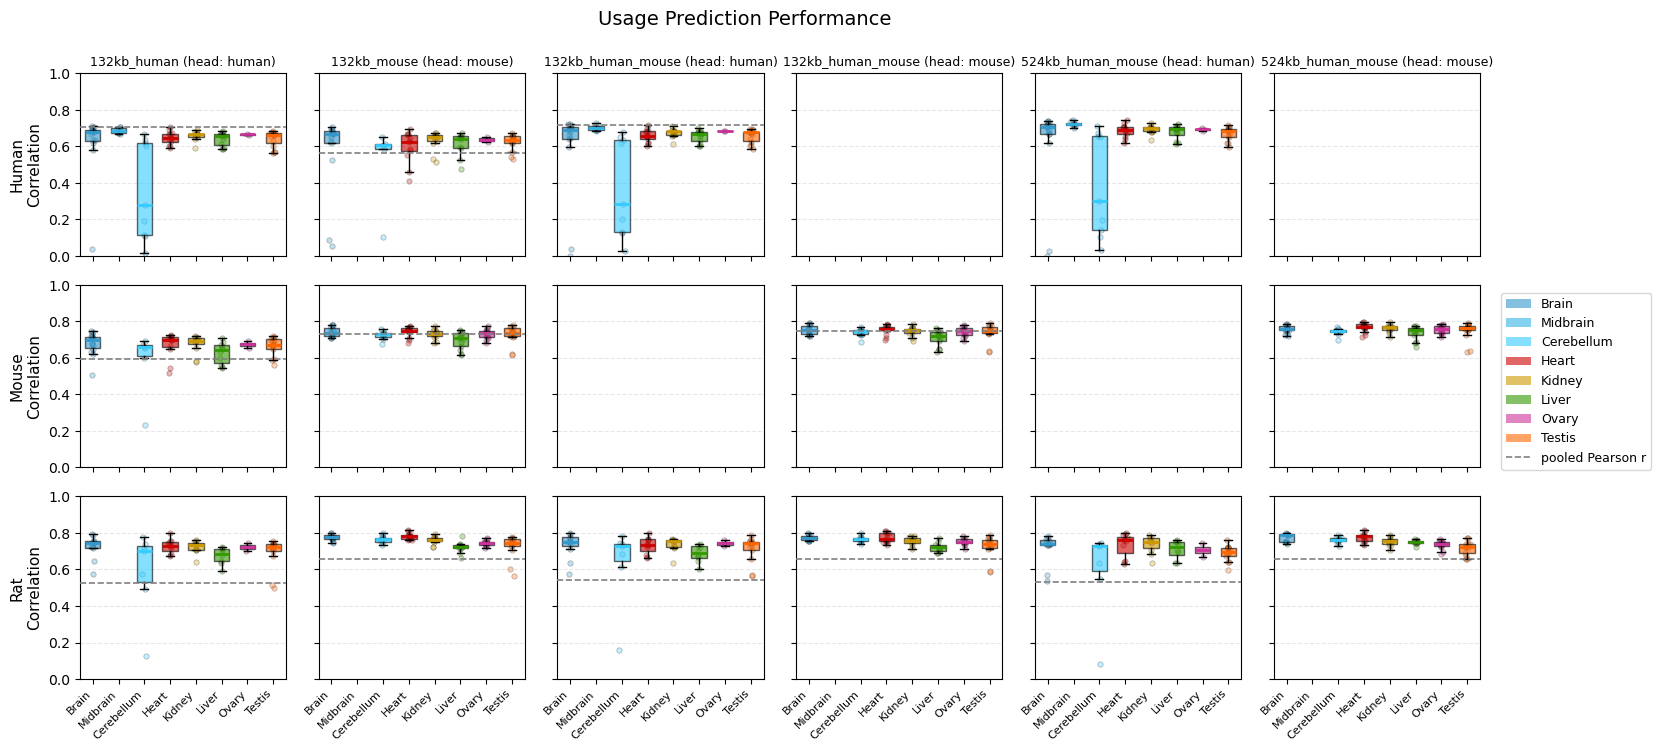

In [8]:

# Grouped boxplot in grid layout: Rows = evaluation species, Columns = model + usage head
# Each subplot shows boxplots for all tissues (even if empty)

def combo_sort_key(combo):
    model = combo.split(' (head:')[0]
    head = combo.split('(head: ')[1].rstrip(')')
    m_rank = MODEL_ORDER.index(model) if model in MODEL_ORDER else len(MODEL_ORDER)
    h_rank = HEAD_ORDER.index(head) if head in HEAD_ORDER else len(HEAD_ORDER)
    return (m_rank, h_rank)

# Get unique prediction species and model+usage_head combinations
pred_species_list = sorted(df_usage['pred_species'].unique())
model_head_combos = sorted(
    df_usage[['model', 'usage_head_species']].drop_duplicates().apply(
        lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique(),
    key=combo_sort_key
)

# Get all tissues across entire dataset for consistent x-axis
tissues = sorted(df_usage['tissue'].unique())
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver',  'Ovary', 'Testis'] 

n_species = len(pred_species_list)
n_combos = len(model_head_combos)
n_tissues = len(tissues)

# Create subplot grid: rows = species, cols = model+head combos
fig, axes = plt.subplots(n_species, n_combos, figsize=(n_combos * 2.5, n_species * 2.5), 
                         squeeze=False, sharex=True, sharey=True)

# Plot each species × model+head combination
for species_idx, pred_sps in enumerate(pred_species_list):
    for combo_idx, combo in enumerate(model_head_combos):
        ax = axes[species_idx, combo_idx]
        
        # Parse combo back to model and usage_head
        model = combo.split(' (head:')[0]
        usage_head = combo.split('(head: ')[1].rstrip(')')
        
        # Filter data for this species, model, and usage head
        subset = df_usage[
            (df_usage['pred_species'] == pred_sps) & 
            (df_usage['model'] == model) &
            (df_usage['usage_head_species'] == usage_head)
        ]
        
        # Prepare boxplot data for ALL tissues (in consistent order)
        box_data = []
        box_positions = []
        box_colors = []
        
        for tissue_idx, tissue in enumerate(tissues):
            tissue_data = subset[subset['tissue'] == tissue]
            if len(tissue_data) > 0:
                box_data.append(tissue_data['correlation'].values)
                box_positions.append(tissue_idx + 1)
                box_colors.append(TISSUE_COLORS.get(tissue, '#888888'))
        
        if box_data:
            # Create boxplot with explicit positions
            bp = ax.boxplot(box_data, positions=box_positions, patch_artist=True,
                           showfliers=False, widths=0.6)
            
            # Color boxes by tissue
            for patch, color in zip(bp['boxes'], box_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
            
            for median, color in zip(bp['medians'], box_colors):
                median.set_color(color)
                median.set_linewidth(2)
            
            # Add scatter points with jitter
            for position, data_points, color in zip(box_positions, box_data, box_colors):
                x_jitter = np.random.normal(position, 0.04, size=len(data_points))
                ax.scatter(x_jitter, data_points, alpha=0.3, s=15,
                          color=color, edgecolors='black', linewidths=0.5)
        
        # Pooled Pearson r from metrics.json as horizontal dashed line
        if len(subset) > 0:
            pooled_r = subset['pooled_r'].iloc[0]
            if np.isfinite(pooled_r):
                ax.axhline(pooled_r, color='grey', linestyle='--', linewidth=1.2, zorder=5)
        
        # Customize subplot
        ax.set_ylim(0, 1)
        ax.set_xlim(0.5, n_tissues + 0.5)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Set title for top row (model + head names)
        if species_idx == 0:
            ax.set_title(combo, fontsize=9)
        
        # Set ylabel for leftmost column (species names)
        if combo_idx == 0:
            ax.set_ylabel(f'{pred_sps.capitalize()}\nCorrelation', fontsize=11)
        
        # Set x-ticks for ALL tissues (consistent across all subplots)
        ax.set_xticks(range(1, n_tissues + 1))
        
        # Only show x-tick labels on bottom row
        if species_idx == n_species - 1:
            ax.set_xticklabels([tissue[:10] for tissue in tissues], 
                              rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticklabels([])

# Add overall title
fig.suptitle('Usage Prediction Performance', 
             fontsize=14, y=0.995)

# Create legend for tissues
from matplotlib.patches import Patch
import matplotlib.lines as mlines
legend_handles = [Patch(facecolor=TISSUE_COLORS.get(tissue, '#888888'), 
                        alpha=0.6, label=tissue) for tissue in tissues]
legend_handles.append(mlines.Line2D([], [], color='grey', linestyle='--',
                                    linewidth=1.2, label='pooled Pearson r'))
fig.legend(handles=legend_handles, 
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


Single plot with all tissues on x-axis

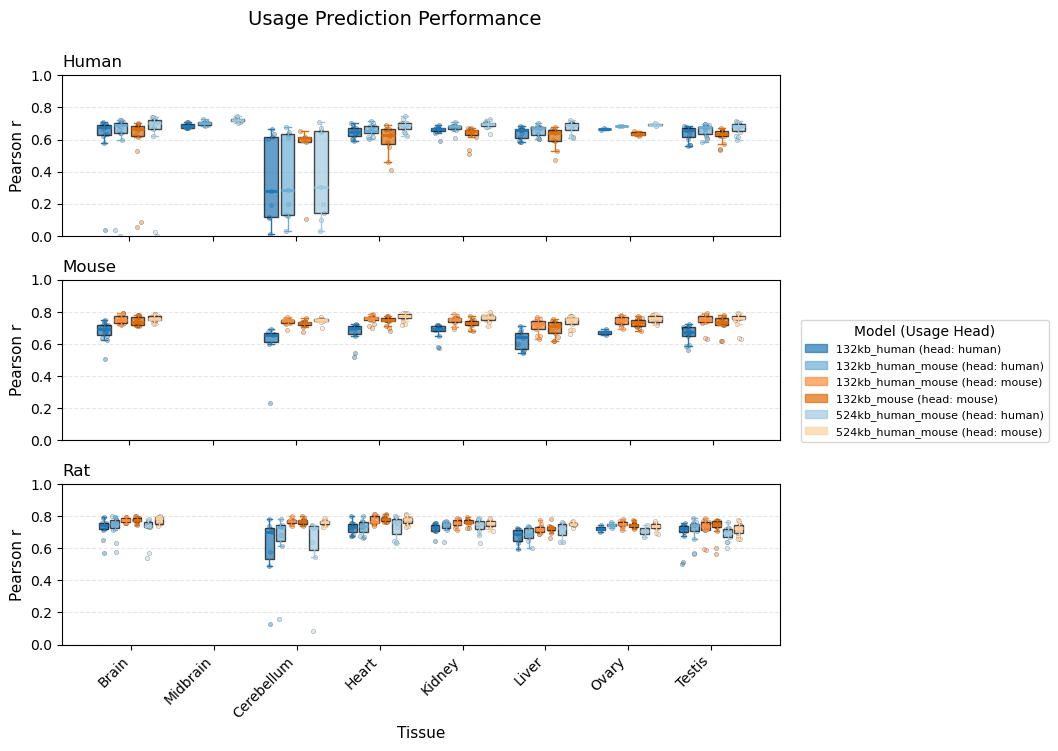

In [9]:
# Alternative: Separate plots by prediction species (in rows), tissues on x-axis with grouped boxplots
import matplotlib.patches as mpatches

tissues = sorted(df_usage['tissue'].unique())
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver',  'Ovary', 'Testis'] 
pred_species_list = sorted(df_usage['pred_species'].unique())

# Get model+head combinations
model_head_combos = sorted(df_usage[['model', 'usage_head_species']].drop_duplicates().apply(
    lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique())

n_tissues = len(tissues)
n_species = len(pred_species_list)

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2.5), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    
    # Filter data for this prediction species
    species_data = df_usage[df_usage['pred_species'] == pred_sps]
    
    # Get groups (model+head combos) for this species
    groups = sorted(species_data[['model', 'usage_head_species']].drop_duplicates().apply(
        lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique())
    
    n_groups = len(groups)
    box_width = 0.8 / n_groups
    
    for tissue_idx, tissue in enumerate(tissues):
        tissue_data = species_data[species_data['tissue'] == tissue]
        
        for group_idx, group in enumerate(groups):
            # Parse group to get model and usage_head
            model = group.split(' (head:')[0]
            usage_head = group.split('(head: ')[1].rstrip(')')
            
            group_data = tissue_data[
                (tissue_data['model'] == model) & 
                (tissue_data['usage_head_species'] == usage_head)
            ]
            
            if len(group_data) > 0:
                correlations = group_data['correlation'].values
                
                # Position for this boxplot
                x_pos = tissue_idx + (group_idx - n_groups/2 + 0.5) * box_width
                
                # Create boxplot
                bp = ax.boxplot([correlations], positions=[x_pos], widths=box_width * 0.8,
                               patch_artist=True, showfliers=False,
                               boxprops=dict(facecolor=models_color[group], alpha=0.7),
                               medianprops=dict(color=models_color[group], linewidth=2),
                               whiskerprops=dict(color=models_color[group]),
                               capprops=dict(color=models_color[group]))
                
                # Add scatter points with jitter
                x_jitter = np.random.normal(x_pos, box_width * 0.1, size=len(correlations))
                ax.scatter(x_jitter, correlations, alpha=0.4, s=10,
                          color=models_color[group], edgecolors='black', linewidths=0.3)

    # Customize x-axis
    ax.set_xticks(range(n_tissues))
    # Only show x-tick labels on bottom subplot
    if species_idx == n_species - 1:
        ax.set_xticklabels(tissues, fontsize=10, rotation=45, ha='right')
        ax.set_xlabel('Tissue', fontsize=11)
    else:
        ax.set_xticklabels([])
    
    
    ax.set_ylabel('Pearson r', fontsize=11)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# Create legend outside on the right (same for all species)
legend_patches = [mpatches.Patch(color=models_color[group], alpha=0.7, label=group) 
                  for i, group in enumerate(groups)]
fig.legend(handles=legend_patches, title='Model (Usage Head)', 
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

fig.suptitle('Usage Prediction Performance', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


Per-condition (timepoint) correlation barplots by species and tissue

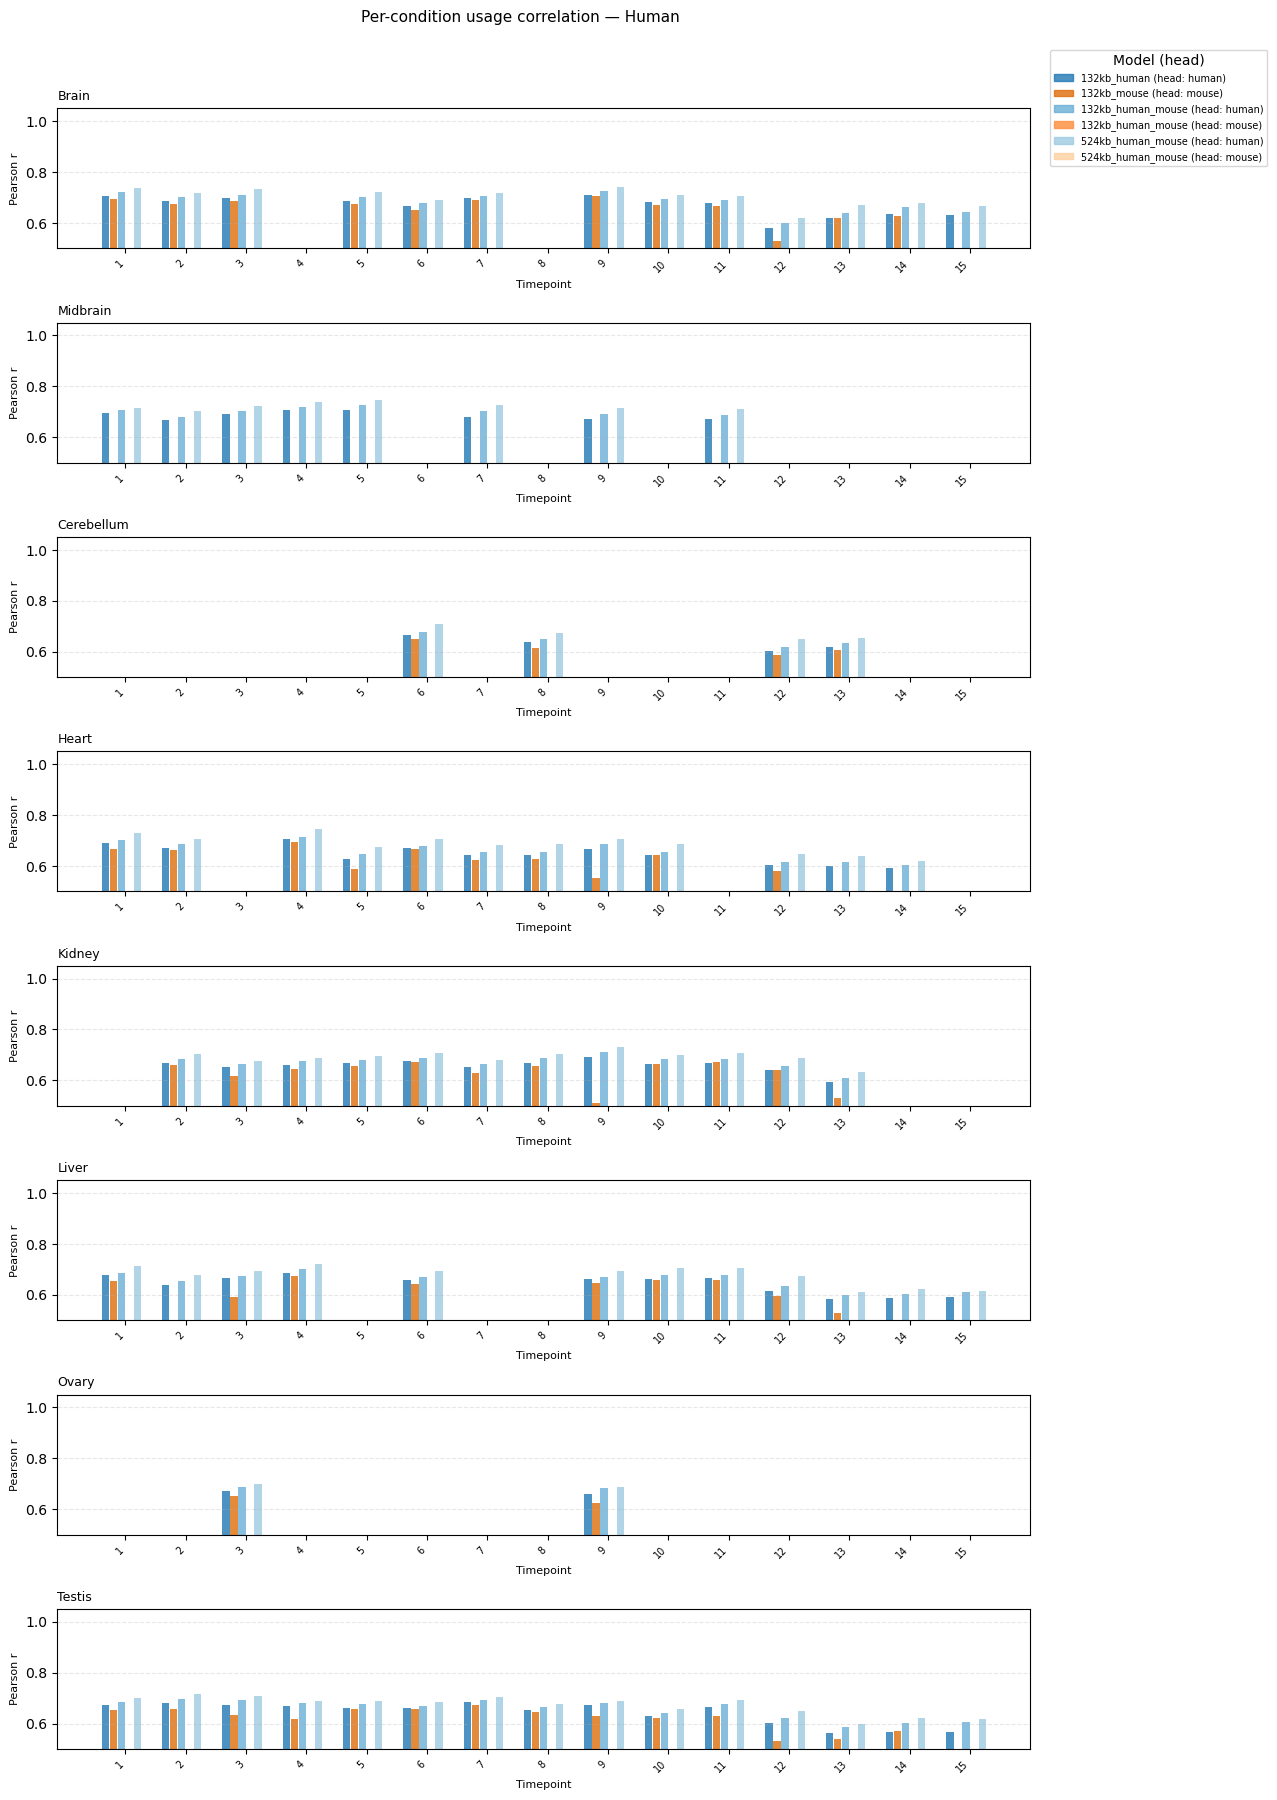

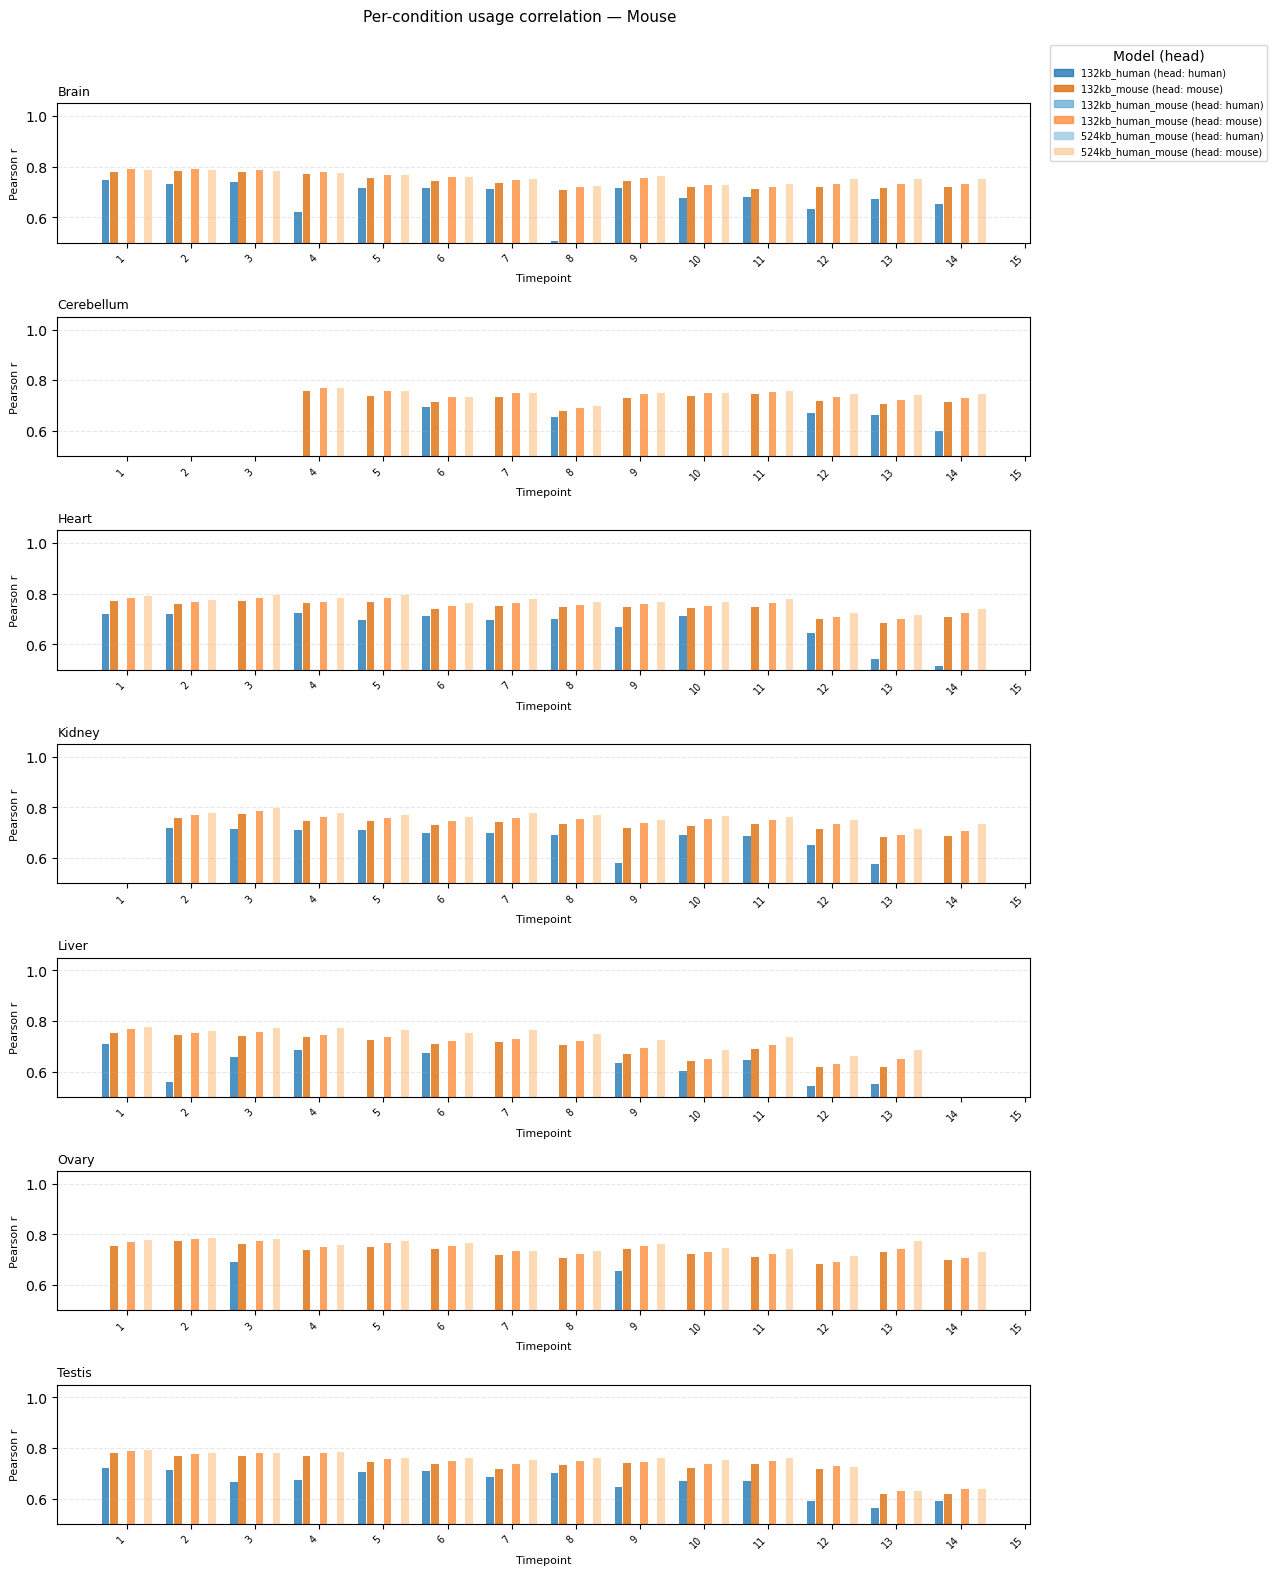

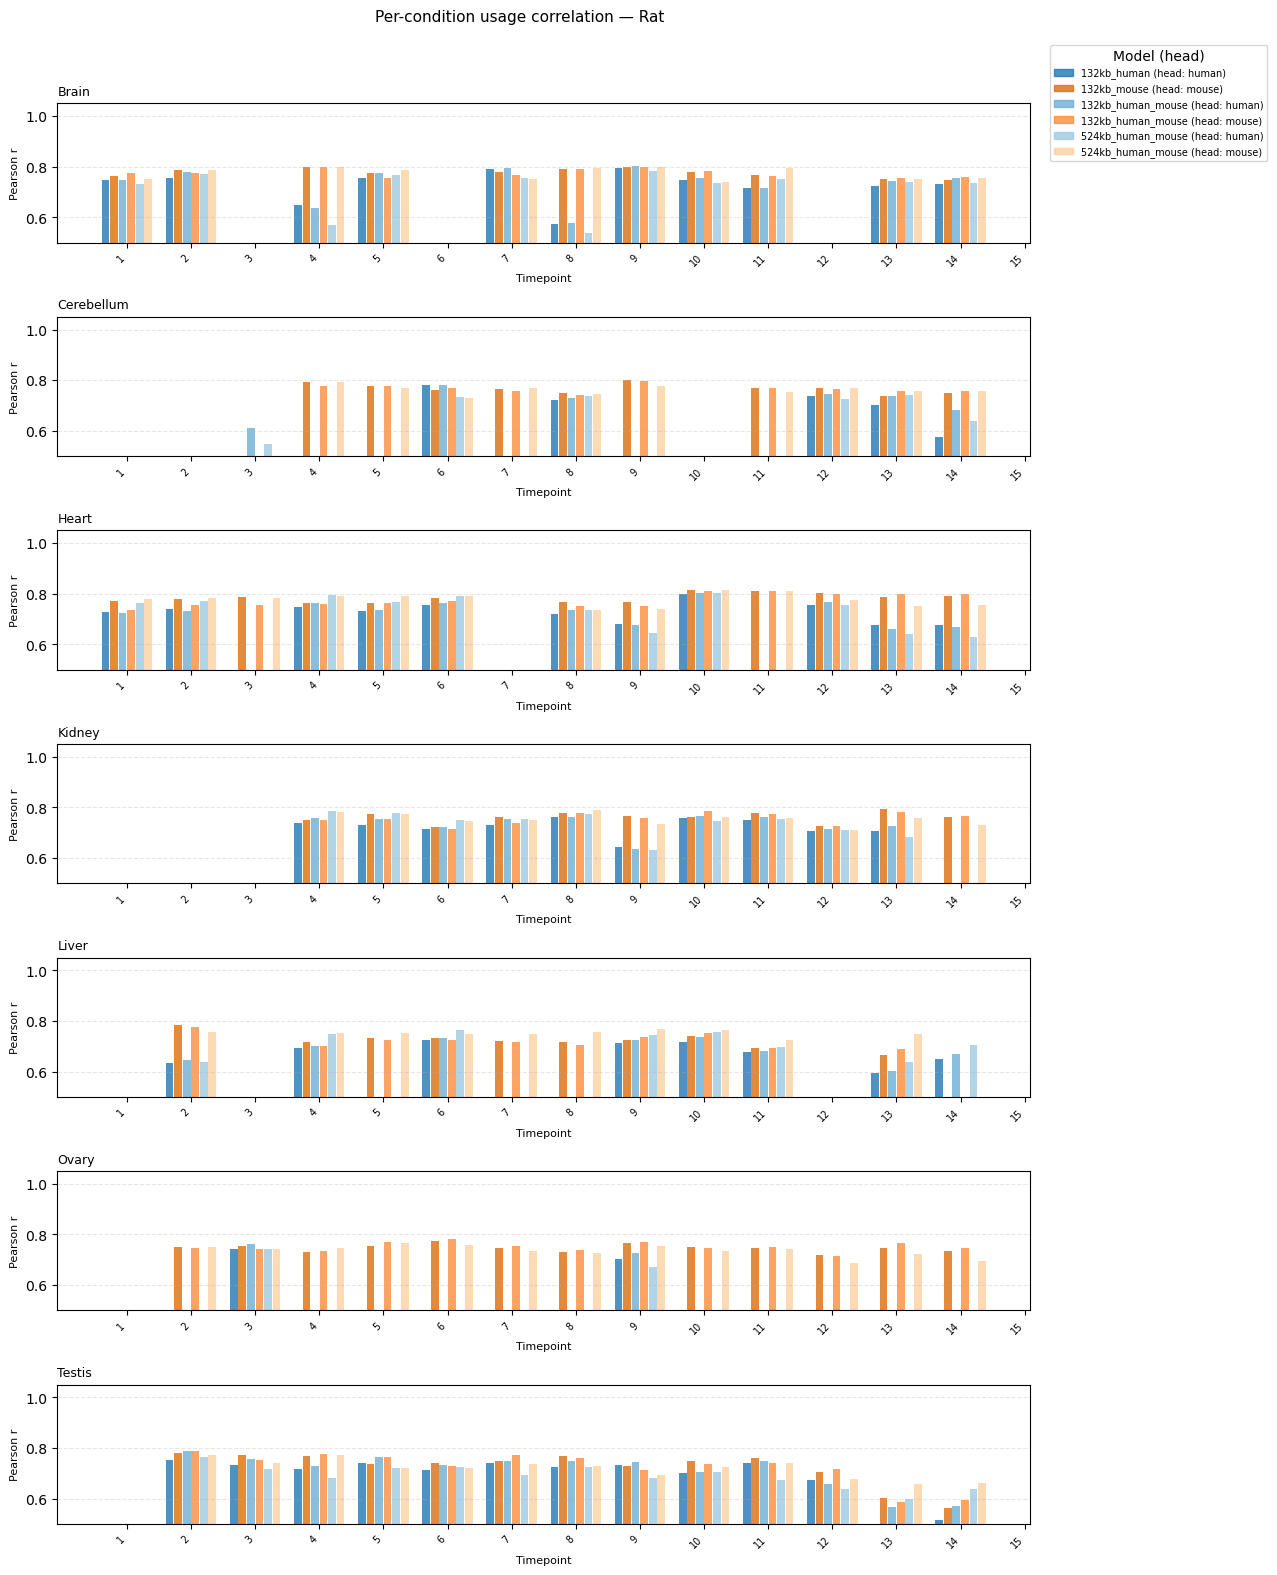

In [14]:
MODEL_ORDER = ["132kb_human", "132kb_mouse", "132kb_human_mouse", "524kb_human_mouse"]
HEAD_ORDER = ["human", "mouse"]

def combo_sort_key(combo):
    model = combo.split(' (head:')[0]
    head = combo.split('(head: ')[1].rstrip(')')
    m_rank = MODEL_ORDER.index(model) if model in MODEL_ORDER else len(MODEL_ORDER)
    h_rank = HEAD_ORDER.index(head) if head in HEAD_ORDER else len(HEAD_ORDER)
    return (m_rank, h_rank)

pred_species_list = sorted(df_usage['pred_species'].unique())
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver', 'Ovary', 'Testis']
tissues = [t for t in tissues if t in df_usage['tissue'].unique()]

# Get all unique timepoints across all tissues and species (for alignment)
all_timepoints = sorted(df_usage['timepoint'].dropna().unique())
if not all_timepoints:
    # Fallback to condition_name if no numeric timepoints
    all_timepoints = sorted(df_usage['condition_name'].unique())
    tp_col = 'condition_name'
else:
    tp_col = 'timepoint'
n_tp = len(all_timepoints)

# All model+head combos in fixed order
all_combos = sorted(
    df_usage[['model', 'usage_head_species']].drop_duplicates().apply(
        lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique(),
    key=combo_sort_key
)
n_combos = len(all_combos)
bar_width = 0.8 / n_combos

for pred_sps in pred_species_list:
    sps_data = df_usage[df_usage['pred_species'] == pred_sps]
    avail_tissues = [t for t in tissues if t in sps_data['tissue'].unique()]
    if not avail_tissues:
        continue

    n_tissues = len(avail_tissues)
    fig, axes = plt.subplots(n_tissues, 1, figsize=(max(4, n_tp * 0.7), n_tissues * 2.2), squeeze=False, sharex=True)
    axes = axes[:, 0]

    for t_idx, tissue in enumerate(avail_tissues):
        ax = axes[t_idx]
        tissue_data = sps_data[sps_data['tissue'] == tissue]

        # Use all_timepoints for alignment
        timepoints = all_timepoints
        n_tp = len(timepoints)
        tp_positions = np.arange(n_tp)

        for c_idx, combo in enumerate(all_combos):
            model = combo.split(' (head:')[0]
            head = combo.split('(head: ')[1].rstrip(')')
            combo_data = tissue_data[(tissue_data['model'] == model) & (tissue_data['usage_head_species'] == head)]
            if combo_data.empty:
                continue

            # One bar per timepoint (aligned, fill with np.nan if missing)
            bar_heights = []
            bar_xpos = []
            for tp_i, tp in enumerate(timepoints):
                row = combo_data[combo_data[tp_col] == tp]
                if not row.empty:
                    bar_heights.append(float(row['correlation'].values[0]))
                else:
                    bar_heights.append(np.nan)
                bar_xpos.append(tp_i + (c_idx - n_combos / 2 + 0.5) * bar_width)

            # Only plot if at least one value is not nan
            if not np.all(np.isnan(bar_heights)):
                ax.bar(bar_xpos, bar_heights, width=bar_width * 0.9,
                       color=models_color[combo], alpha=0.8,
                       label=combo if t_idx == 0 else None)

        ax.set_xticks(tp_positions)
        ax.set_xticklabels(timepoints, rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0.5, 1.05)
        ax.set_title(tissue, fontsize=9, loc='left')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylabel('Pearson r', fontsize=8)
        ax.set_xlabel('Timepoint', fontsize=8)

    for ax in axes:
        ax.set_xticklabels(timepoints, rotation=45, ha='right', fontsize=7)
        ax.xaxis.set_tick_params(labelbottom=True)

    fig.suptitle(f'Per-condition usage correlation — {pred_sps.capitalize()}', fontsize=11, y=1.02)
    
    # Shared legend outside
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=models_color[c], alpha=0.8, label=c) for c in all_combos]
    fig.legend(handles=handles, title='Model (head)', loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=7)

    plt.tight_layout()
    plt.show()


## Summary

In [11]:
# Summary: Classification AUPRC by model and species
summary_classification = df_classification.groupby(['model', 'pred_species'])['auprc'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(3)
print("Classification AUPRC Summary:")
display(summary_classification.round(3))

Classification AUPRC Summary:


mean  median    std  n_conditions
model             pred_species                                    
132kb_human       human         0.888   0.892  0.007             5
                  mouse         0.793   0.779  0.049             5
                  rat           0.850   0.850  0.018             5
132kb_human_mouse human         0.889   0.890  0.005            10
                  mouse         0.799   0.790  0.045            10
                  rat           0.856   0.859  0.016            10
132kb_mouse       human         0.877   0.878  0.007             5
                  mouse         0.790   0.774  0.050             5
                  rat           0.837   0.835  0.023             5
524kb_human_mouse mouse         0.786   0.772  0.046            10
                  rat           0.855   0.844  0.026            10

In [12]:
# Summary: Usage correlations by model and tissue
summary_usage = df_usage.groupby(['tissue', 'model', 'usage_head_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(3)

print("Usage Correlation Summary by Tissue and Model:")
display(summary_usage)

# Overall Summary: Usage correlations by model
overall_summary = df_usage.groupby(['model', 'usage_head_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(3)

print("\nOverall Usage Correlation Summary by Model:")
display(overall_summary)

Usage Correlation Summary by Tissue and Model:


mean  median  \
tissue model             usage_head_species pred_species                  
Brain  132kb_human       human              human         0.580   0.680   
                                            mouse         0.680   0.696   
                                            rat           0.725   0.746   
       132kb_human_mouse human              human         0.594   0.689   
                                            rat           0.734   0.753   
...                                                         ...     ...   
Testis 132kb_mouse       mouse              rat           0.724   0.747   
       524kb_human_mouse human              human         0.672   0.687   
                                            rat           0.690   0.695   
                         mouse              mouse         0.746   0.761   
                                            rat           0.719   0.725   

                                                            std  n_conditions  
tissue model             usage_head_species pred_species                       
Brain  132kb_human       human              human         0.234            15  
                                            mouse         0.064            14  
                                            rat           0.064            11  
       132kb_human_mouse human              human         0.236            15  
                                            rat           0.069            11  
...                                                         ...           ...  
Testis 132kb_mouse       mouse              rat           0.067            13  
       524kb_human_mouse human              human         0.036            15  
                                            rat           0.044            13  
                         mouse              mouse         0.050            14  
                                            rat           0.038            13  

[101 rows x 4 columns]


Overall Usage Correlation Summary by Model:


mean  median    std  \
model             usage_head_species pred_species                         
132kb_human       human              human         0.609   0.662  0.159   
                                     mouse         0.659   0.678  0.077   
                                     rat           0.697   0.724  0.098   
132kb_human_mouse human              human         0.623   0.677  0.159   
                                     rat           0.712   0.737  0.091   
                  mouse              mouse         0.741   0.749  0.034   
                                     rat           0.753   0.758  0.037   
132kb_mouse       mouse              human         0.601   0.641  0.126   
                                     mouse         0.728   0.735  0.036   
                                     rat           0.754   0.763  0.039   
524kb_human_mouse human              human         0.641   0.691  0.165   
                                     rat           0.704   0.734  0.101   
                  mouse              mouse         0.754   0.760  0.031   
                                     rat           0.753   0.754  0.031   

                                                   n_conditions  
model             usage_head_species pred_species                
132kb_human       human              human                   85  
                                     mouse                   70  
                                     rat                     62  
132kb_human_mouse human              human                   85  
                                     rat                     62  
                  mouse              mouse                   93  
                                     rat                     81  
132kb_mouse       mouse              human                   69  
                                     mouse                   93  
                                     rat                     81  
524kb_human_mouse human              human                   85  
                                     rat                     62  
                  mouse              mouse                   93  
                                     rat                     81